Импортируем все необходимые библиотеки

In [ ]:
import os, re, html, json, random, warnings, unicodedata
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize, differential_evolution
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

SEED = 322
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')
device = torch.device('cuda')
print(f"Seed={SEED} | Device={device}")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')




In [2]:
train = pd.read_csv('train.csv', sep='\t')
test  = pd.read_csv('test.csv', sep='\t')

In [4]:
train.head()

,id,source,title,text,publication_date,target
0,0,Novosti,Рейтинг регионов по уровню закредитованности н...,Средний <content>уровень</content> <source>ria...,2019-12-23 00:00,"[0, 1, 0, 0, 0]"
1,1,Novosti,Названы самые закредитованные российские регионы,"МОСКВА, 23 дек — РИА Новости. Наиболее закре...",2019-12-23 00:21,"[0, 1, 0, 0, 0]"
2,2,Novosti,В России пройдут учения по обеспечению устойчи...,"МОСКВА, 23 дек - РИА Новости. Всероссийские у...",2019-12-23 00:28,"[1, 0, 0, 1, 0]"
3,3,Novosti,Самолеты НАТО стали чаще летать у границ Росси...,"МОСКВА, 23 дек - РИА 📄 Новости. <hr> 📝 Интенс...",2019-12-23 00:39,"[1, 0, 0, 0, 0]"
4,4,Novosti,Сюткин оценил шутку Шнурова над обидевшим Гага...,"МОСКВА, &nbsp;23 дек — РИА </content> Новости....",2019-12-23 00:50,"[0, 0, 0, 0, 0]"


In [3]:
# Загрузка данных
print(f"Train: {train.shape} | Test: {test.shape}")
print(f"Колонки в train: {train.columns.tolist()}")
print(f"Типы данных: {train.dtypes}")
print(f"Пропуски в train: {train.isnull().sum()}")
print(f"Пропуски в test: {test.isnull().sum()}")

# Первые 3 строки для понимания структуры
print()
for idx in range(3):
    print(f"\n--- Row {idx} ---")
    print(f"ID: {train.iloc[idx]['id']}")
    print(f"Source: {train.iloc[idx]['source']}")
    print(f"Title: {train.iloc[idx]['title'][:100]}...")
    print(f"Text: {train.iloc[idx]['text'][:150]}...")
    print(f"Target: {train.iloc[idx]['target']}")

Train: (16701, 6) | Test: (4969, 5)
Колонки в train: ['id', 'source', 'title', 'text', 'publication_date', 'target']
Типы данных: id                   int64
source              object
title               object
text                object
publication_date    object
target              object
dtype: object
Пропуски в train: id                  0
source              0
title               0
text                0
publication_date    0
target              0
dtype: int64
Пропуски в test: id                  0
source              0
title               0
text                0
publication_date    0
dtype: int64


--- Row 0 ---
ID: 0
Source: Novosti
Title: Рейтинг регионов по уровню закредитованности населения — 2019...
Text: Средний <content>уровень</content> <source>ria.ru</source> 💰 закредитованности ⚡ <<em>content> <strong>россиян ✨ вырос</strong</em>> <![CDATA[ за 📍 <h...
Target: [0, 1, 0, 0, 0]

--- Row 1 ---
ID: 1
Source: Novosti
Title: Названы самые закредитованные российские регионы...
T

Матрица таргетов: (16701, 5)
Всего примеров: 16701
Частота классов:
  Класс 0: 7145 примеров (42.78%)
  Класс 1: 2276 примеров (13.63%)
  Класс 2: 1836 примеров (10.99%)
  Класс 3: 1243 примеров ( 7.44%)
  Класс 4:  544 примеров ( 3.26%)


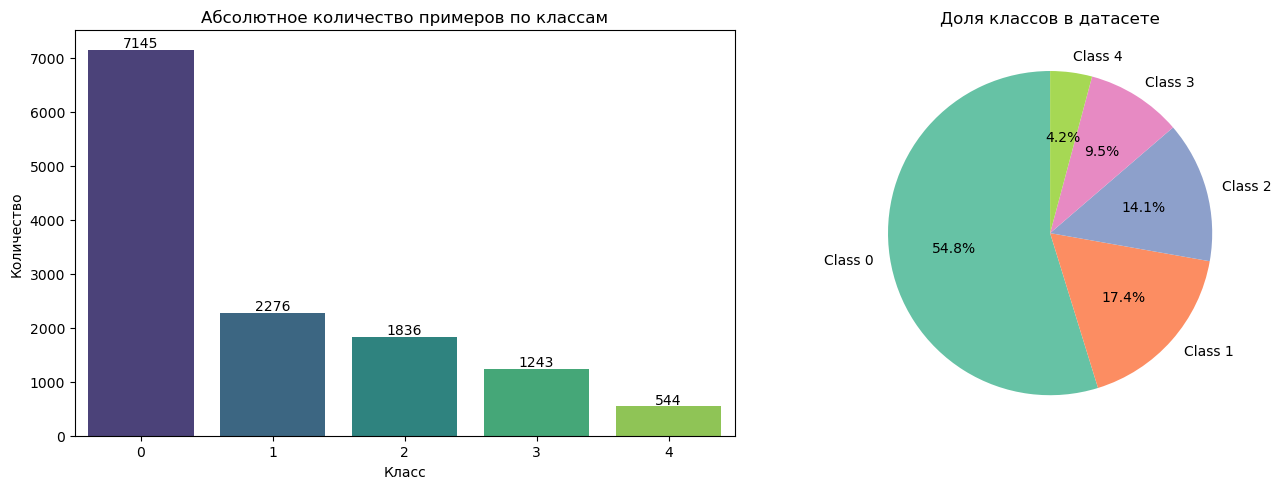

In [4]:
import json

# Парсинг таргетов
def parse_target(x):
    try:
        return json.loads(str(x).replace("'", '"'))
    except:
        return [0]*5

train['target_vec'] = train['target'].apply(parse_target)
y_matrix = np.array(train['target_vec'].tolist())

print(f"Матрица таргетов: {y_matrix.shape}")
print(f"Всего примеров: {len(train)}")


class_counts = y_matrix.sum(axis=0)
class_freq = class_counts / len(train) * 100

print("Частота классов:")
for i, (cnt, freq) in enumerate(zip(class_counts, class_freq)):
    print(f"  Класс {i}: {cnt:4d} примеров ({freq:5.2f}%)")

# Визуализация распределения классов
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Бар-чарт
sns.barplot(x=range(5), y=class_counts, ax=ax[0], palette='viridis')
ax[0].set_title('Абсолютное количество примеров по классам')
ax[0].set_xlabel('Класс')
ax[0].set_ylabel('Количество')
for i, v in enumerate(class_counts):
    ax[0].text(i, v + 50, str(int(v)), ha='center')

# Pie-чарт
ax[1].pie(class_freq, labels=[f'Class {i}' for i in range(5)], 
          autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
ax[1].set_title('Доля классов в датасете')

plt.tight_layout()
plt.show()

In [5]:
from itertools import combinations
from sklearn.preprocessing import MultiLabelBinarizer

# Анализ комбинаций меток
label_combinations = Counter()
for labels in train['target_vec']:
    active = tuple(i for i, v in enumerate(labels) if v == 1)
    label_combinations[active] += 1

print(f"Уникальных комбинаций меток: {len(label_combinations)}")
print("Наиболее частых комбинаций:")
for combo, count in label_combinations.most_common(10):
    labels_str = ', '.join([f'C{i}' for i in combo]) if combo else 'None'
    print(f"  [{labels_str:15s}] : {count:4d} примеров ({count/len(train)*100:.2f}%)")

Уникальных комбинаций меток: 28
Наиболее частых комбинаций:
  [C0             ] : 5766 примеров (34.52%)
  [None           ] : 5643 примеров (33.79%)
  [C2             ] : 1455 примеров (8.71%)
  [C1             ] : 1169 примеров (7.00%)
  [C0, C1         ] :  689 примеров (4.13%)
  [C3             ] :  516 примеров (3.09%)
  [C4             ] :  303 примеров (1.81%)
  [C0, C3         ] :  301 примеров (1.80%)
  [C1, C3         ] :  246 примеров (1.47%)
  [C0, C2         ] :  171 примеров (1.02%)


Статистика длин текстов:
  Title:  mean=60, median=63, max=82
  Text:   mean=2063, median=1762, max=26239
  Combined: mean=2123, median=1822, max=26295


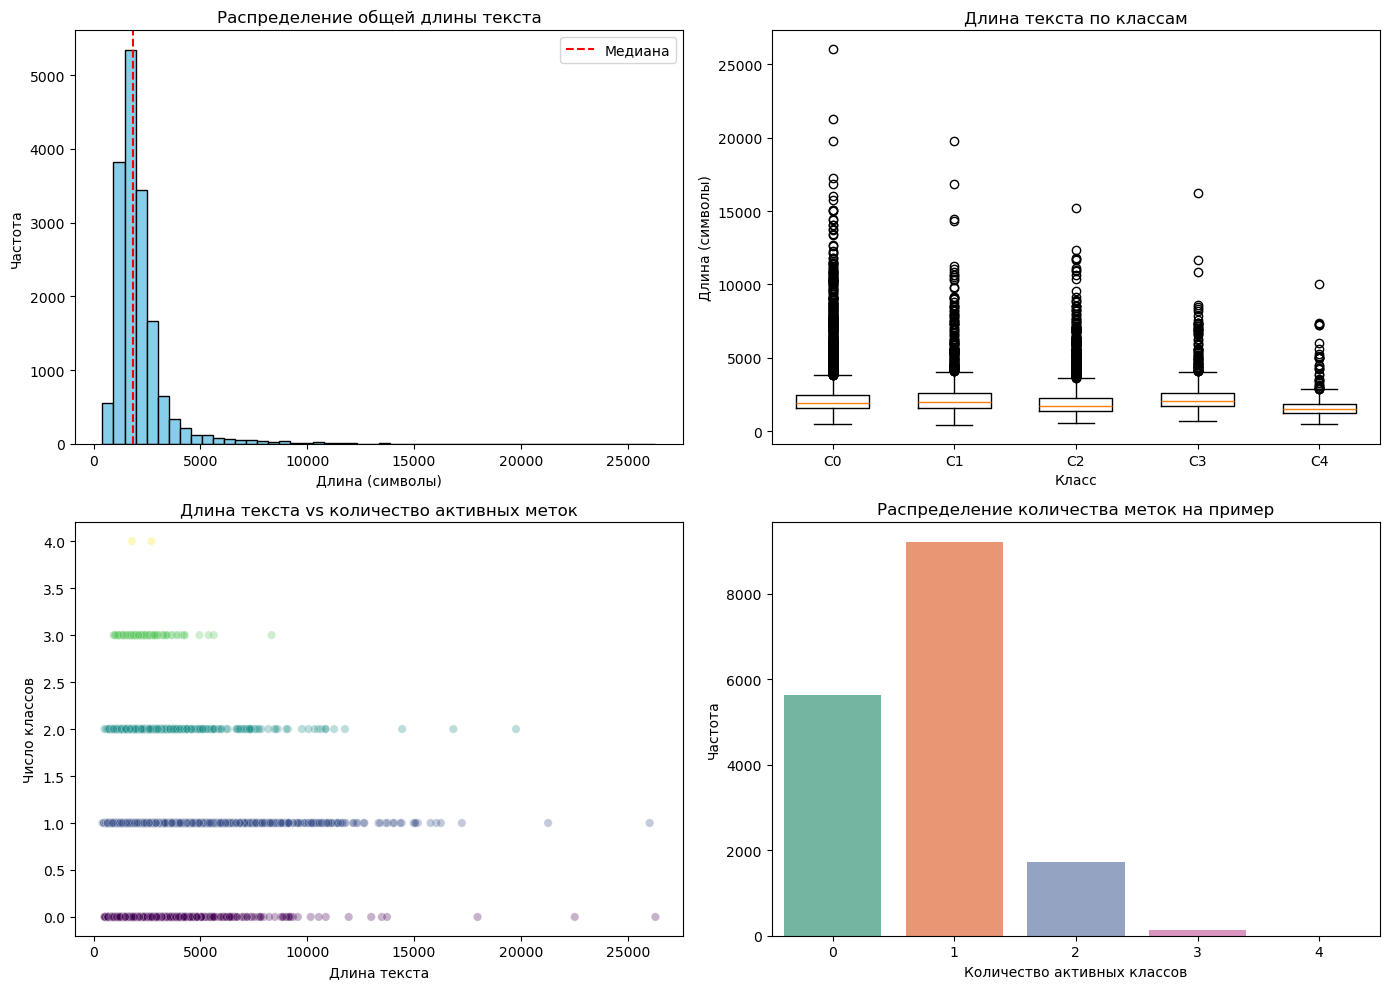

In [6]:
# Вычисление длин
train['title_len'] = train['title'].astype(str).str.len()
train['text_len'] = train['text'].astype(str).str.len()
train['combined_len'] = train['title_len'] + train['text_len']

print(f"Статистика длин текстов:")
print(f"  Title:  mean={train['title_len'].mean():.0f}, median={train['title_len'].median():.0f}, max={train['title_len'].max()}")
print(f"  Text:   mean={train['text_len'].mean():.0f}, median={train['text_len'].median():.0f}, max={train['text_len'].max()}")
print(f"  Combined: mean={train['combined_len'].mean():.0f}, median={train['combined_len'].median():.0f}, max={train['combined_len'].max()}")

# Визуализация распределения длин
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма combined length
axes[0, 0].hist(train['combined_len'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].axvline(train['combined_len'].median(), color='red', linestyle='--', label='Медиана')
axes[0, 0].set_title('Распределение общей длины текста')
axes[0, 0].set_xlabel('Длина (символы)')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

# Boxplot по классам
for i in range(5):
    axes[0, 1].boxplot([train.loc[y_matrix[:, i] == 1, 'combined_len'].dropna()], 
                       labels=[f'C{i}'], positions=[i], widths=0.6)
axes[0, 1].set_title('Длина текста по классам')
axes[0, 1].set_xlabel('Класс')
axes[0, 1].set_ylabel('Длина (символы)')


train['num_labels'] = y_matrix.sum(axis=1)
sns.scatterplot(data=train, x='combined_len', y='num_labels', 
                alpha=0.3, ax=axes[1, 0], hue='num_labels', palette='viridis', legend=False)
axes[1, 0].set_title('Длина текста vs количество активных меток')
axes[1, 0].set_xlabel('Длина текста')
axes[1, 0].set_ylabel('Число классов')

# Гистограмма по количеству меток
sns.countplot(data=train, x='num_labels', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Распределение количества меток на пример')
axes[1, 1].set_xlabel('Количество активных классов')
axes[1, 1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

  Novosti                        : 12759 (76.4%)
  Svezhesti                      : 3942 (23.6%)


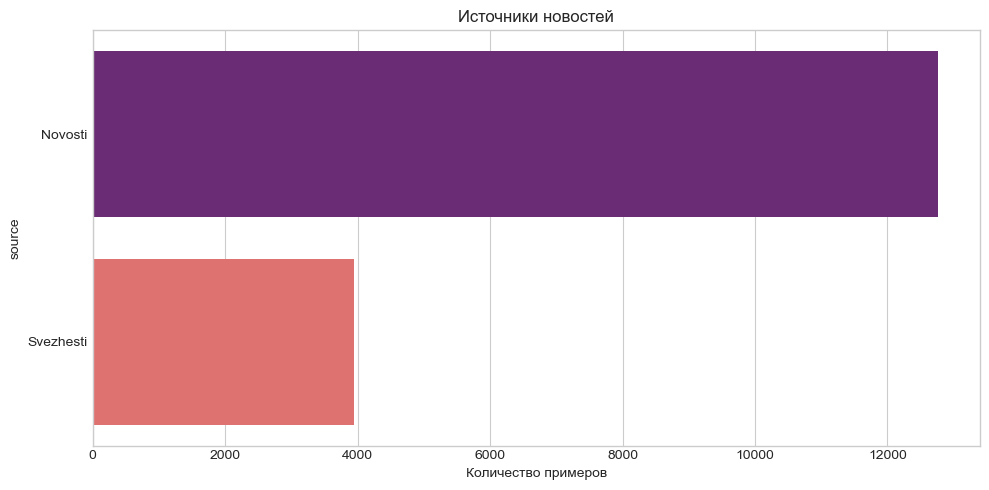

Диапазон дат: 2019-12-23 00:00:00 — 2020-07-30 23:59:00
Примеров по годам:
pub_year
2019      229
2020    16472
Name: count, dtype: int64


<Figure size 1200x600 with 0 Axes>

In [13]:

source_counts = train['source'].value_counts().head(10)
for src, cnt in source_counts.items():
    print(f"  {src:30s} : {cnt:4d} ({cnt/len(train)*100:.1f}%)")

plt.figure(figsize=(10, 5))
sns.barplot(x=source_counts.values, y=source_counts.index, palette='magma')
plt.title('Источники новостей')
plt.xlabel('Количество примеров')
plt.tight_layout()
plt.show()

# Анализ даты публикации
train['publication_date'] = pd.to_datetime(train['publication_date'], errors='coerce')
train['pub_year'] = train['publication_date'].dt.year
train['pub_month'] = train['publication_date'].dt.month

print(f"Диапазон дат: {train['publication_date'].min()} — {train['publication_date'].max()}")
print(f"Примеров по годам:\n{train['pub_year'].value_counts().sort_index()}")


plt.tight_layout()
plt.show()

Анализ артефактов (выборка 1000 примеров):
  html_tags   : встречается в 1000 текстах (100.0%), max=76, mean=16.76
  cdata       : встречается в  664 текстах (66.4%), max=13, mean=0.98
  comments    : встречается в  763 текстах (76.3%), max=8, mean=0.87
  entities    : встречается в  996 текстах (99.6%), max=29, mean=5.40
  emojis      : встречается в  996 текстах (99.6%), max=32, mean=5.93
  wp_blocks   : встречается в  363 текстах (36.3%), max=4, mean=0.24


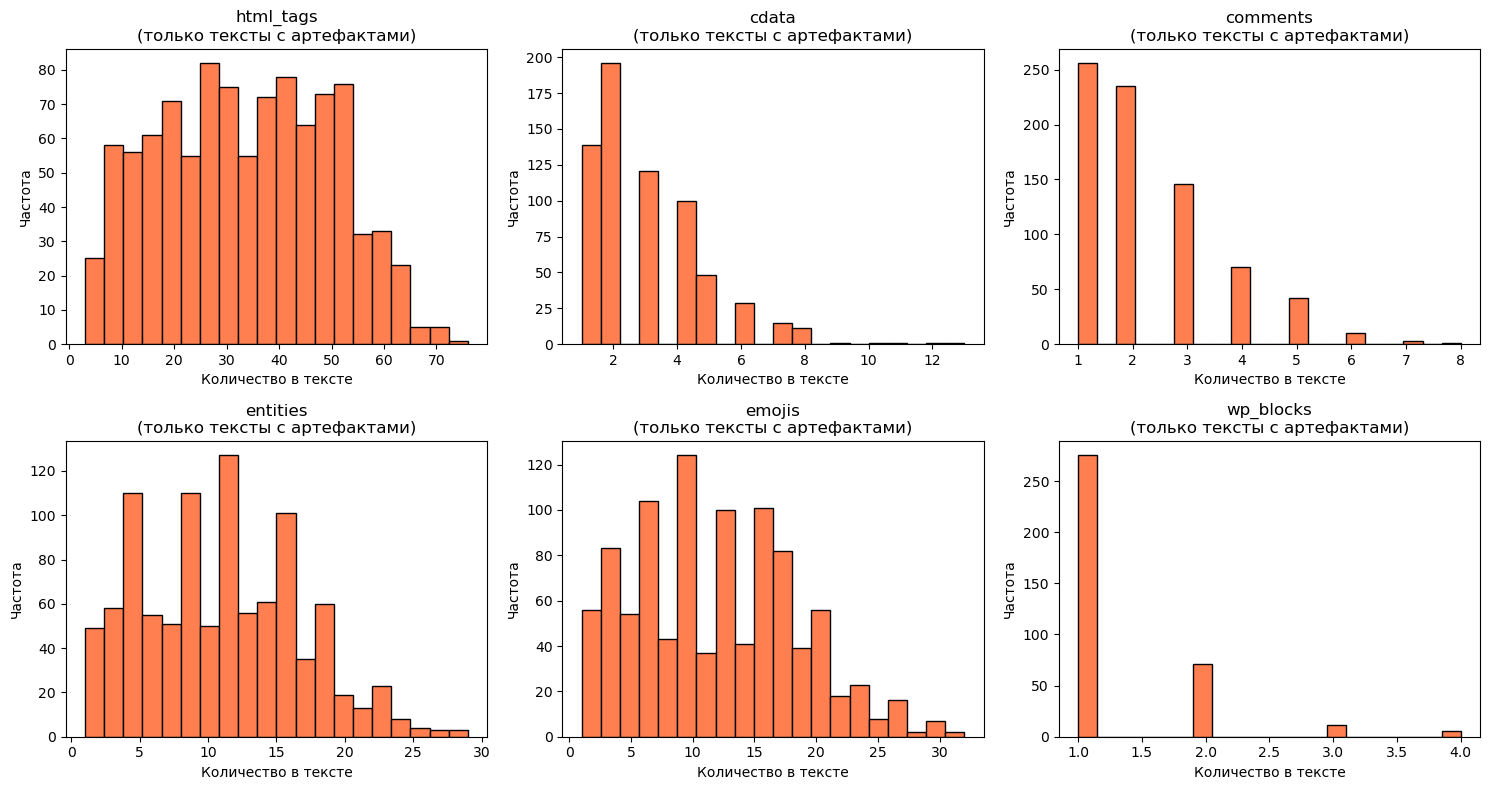

In [7]:
def count_artifacts(text):
    if pd.isna(text):
        return {'html_tags': 0, 'cdata': 0, 'comments': 0, 'entities': 0, 'emojis': 0, 'wp_blocks': 0}
    t = str(text)
    return {
        'html_tags': len(re.findall(r'<[^>]+>', t)),
        'cdata': len(re.findall(r'<!\[CDATA\[|\]\]>', t)),
        'comments': len(re.findall(r'<!--.*?-->', t, flags=re.DOTALL)),
        'entities': len(re.findall(r'&[a-zA-Z0-9#]+;', t)),
        'emojis': len(re.findall(r'[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF]', t)),
        'wp_blocks': len(re.findall(r'<!--\s*/?wp:[^>]*\s*-->', t))
    }


sample_size = min(1000, len(train))
sample = train.sample(sample_size, random_state=322)

artifact_stats = {'html_tags': [], 'cdata': [], 'comments': [], 'entities': [], 'emojis': [], 'wp_blocks': []}
for col in ['title', 'text']:
    for txt in sample[col]:
        counts = count_artifacts(txt)
        for k in artifact_stats:
            artifact_stats[k].append(counts[k])

print(f"Анализ артефактов (выборка {sample_size} примеров):")
for artifact, values in artifact_stats.items():
    nonzero = sum(1 for v in values if v > 0)
    print(f"  {artifact:12s}: встречается в {nonzero:4d} текстах ({nonzero/sample_size*100:.1f}%), "
          f"max={max(values)}, mean={np.mean(values):.2f}")


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for idx, (artifact, values) in enumerate(artifact_stats.items()):
    axes[idx].hist([v for v in values if v > 0], bins=20, color='coral', edgecolor='black')
    axes[idx].set_title(f'{artifact}\n(только тексты с артефактами)')
    axes[idx].set_xlabel('Количество в тексте')
    axes[idx].set_ylabel('Частота')
plt.tight_layout()
plt.show()


In [17]:
import unicodedata
from tqdm.auto import tqdm


tqdm.pandas()

def clean_text_ultimate(text):
    if pd.isna(text):
        return ""
    t = str(text)
    
    #Удаляю маркеры CDATA, HTML, XML 
    t = t.replace('<![CDATA[', ' ').replace(']]>', ' ')
    t = t.replace('<!--', ' ').replace('-->', ' ')
    t = t.replace('<?xml', ' ').replace('<meta', ' ')
    t = re.sub(r'<[^>]*>', ' ', t)
    t = re.sub(r'&[a-zA-Z0-9#]+;', ' ', t)
    
    #Оставляю только кириллицу, латиницу, цифры и базовую пунктуацию
    t = re.sub(r'[^\w\sа-яА-ЯёЁa-zA-Z0-9.,!?;:\'\"\-–—]', ' ', t)
    
    #нормализация + схлопывание пробелов + нижний регистр
    t = unicodedata.normalize('NFKC', t)
    t = re.sub(r'\s+', ' ', t).strip().lower()
    
    return t


#очищаю train датасет
train_raw = train['title'].fillna('').astype(str) + ' ' + train['text'].fillna('').astype(str)
train['clean'] = train_raw.progress_apply(clean_text_ultimate)

#очищаю test датасет
test_raw = test['title'].fillna('').astype(str) + ' ' + test['text'].fillna('').astype(str)
test['clean'] = test_raw.progress_apply(clean_text_ultimate)

def parse_target(x):
    try:
        return json.loads(str(x).replace("'", '"'))
    except Exception:
        return [0, 0, 0, 0, 0]

train['target_vec'] = train['target'].progress_apply(parse_target)
y_full = np.array(train['target_vec'].tolist())


  0%|          | 0/16701 [00:00<?, ?it/s]

  0%|          | 0/4969 [00:00<?, ?it/s]

  0%|          | 0/16701 [00:00<?, ?it/s]

In [19]:
MODEL_NAME = "ai-forever/ruRoberta-large"  # Загружаю большую модель
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class NewsDataset(Dataset):
    def __init__(self, texts, labels=None, max_len=384):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], padding='max_length', truncation=True, 
                        max_length=self.max_len, return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


X_tr, X_val, y_tr, y_val = train_test_split(
    train['clean'].values, y_full, test_size=0.15, random_state=SEED
)

BATCH_SIZE = 24  
train_ds = NewsDataset(X_tr, y_tr)
val_ds = NewsDataset(X_val, y_val)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2)

NameError: name 'AutoTokenizer' is not defined

In [ ]:
from torch.cuda.amp import autocast, GradScaler

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=5, problem_type="multi_label_classification"
)
model.gradient_checkpointing_enable()  # Экономия памяти
model = nn.DataParallel(model).to(device)  # T4×2

#переобучаем веса
pos_weights = torch.tensor(1.0 - y_full.mean(axis=0) + 1e-6, device=device)
scaler = GradScaler()

def train_epoch(model, dl, optimizer, scheduler):
    model.train()
    for batch in tqdm(dl, desc="Train", leave=False):
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(input_ids, attention_mask=attn_mask)
            loss = F.binary_cross_entropy_with_logits(
                outputs.logits, labels, pos_weight=pos_weights
            )
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

def eval_model(model, dl):
    model.eval()
    probs, trues = [], []
    with torch.no_grad():
        for batch in tqdm(dl, desc="Val"):
            out = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            probs.append(torch.sigmoid(out.logits).cpu().numpy())
            trues.append(batch['labels'].numpy())
    return np.vstack(probs), np.vstack(trues)

# Обучение
optimizer = torch.optim.AdamW(model.parameters(), lr=1.5e-5, weight_decay=1e-3)
total_steps = len(train_dl) * 3
scheduler = get_linear_schedule_with_warmup(optimizer, 0.1*total_steps, total_steps)

for epoch in range(3):
    train_epoch(model, train_dl, optimizer, scheduler)
    val_probs, val_labels = eval_model(model, val_dl)
    print(f"  Epoch {epoch+1} done")

In [ ]:
def hamming_score(y_true, y_pred):
    return np.mean((y_true == y_pred).sum(axis=1) / y_true.shape[1])

# Целевая функция для scipy.optimize
def neg_hamming(thresholds, probs, y_true):
    thresholds = np.clip(thresholds, 0.05, 0.95)
    preds = (probs >= thresholds).astype(int)
    return -hamming_score(y_true, preds)

bounds = [(0.1, 0.85)] * 5
res = differential_evolution(
    neg_hamming, bounds, args=(val_probs, val_labels),
    seed=SEED, maxiter=200, tol=1e-7, polish=True
)
opt_thresh = np.clip(res.x, 0.1, 0.85)
val_score = -res.fun
print(f"Оптимальные пороги: {np.round(opt_thresh, 3)}")
print(f"Val Hamming Score: {val_score:.4f} | Baseline 2: 0.95832")

In [ ]:
#Инференс
test_ds = NewsDataset(test['clean'].values)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2)

model.eval()
probs_test = []
with torch.no_grad():
    for batch in tqdm(test_dl, desc="Test"):
        out = model(batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
        probs_test.append(torch.sigmoid(out.logits).cpu().numpy())
probs_test = np.vstack(probs_test)

#Применение порогов
preds_test = (probs_test >= opt_thresh).astype(int)
formatted = ["[" + ",".join(map(str, p)) + "]" for p in preds_test]

submission = pd.DataFrame({'id': test['id'], 'target': formatted})
submission.to_csv('sample_submission.csv', index=False)
submission.head()